## Figure 3: Building duplex consensus metrics and metrics compilation output

This script is used to generate the following plots:

**e**: Percentage of molecules aligned within the targeted regions for 10 different experiments, generated by the Integrated duplex metrics.

**f** and **g**: Optimal libraries



In [1]:
# --- 1. Setup: imports --------------------------------------------------------

import pandas as pd
import os
import re
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
import numpy as np

In [2]:
# --- 2. Paths -------------------------------------------------
# Wetlab analysis data
wetlab_analysis_dir = '/data/bbg/projects/prominent/analysis/wetlab_analysis/data'

# Plots directory
plotsdir = f"{wetlab_analysis_dir}/plots"

# Integrated duplex metrics
data = pd.read_table("/data/bbg/projects/prominent/analysis/wetlab_analysis/data/output_data/2026-03-18.WetDryMetrics.tsv")

In [3]:
data["OptimalReadXDuplexRead"] = (data['FamMetrics>>total_GBs_for_optimal']/300*1e9) / data['FamMetrics>>all.duplex.dscs']

In [4]:
subset_data_IDT = pd.read_table("../SelectedMetrics_deepDLP - Sup. Table 4_ deepDLP duplex metrics.tsv")
subset_data_MNE = pd.read_table("../SelectedMetrics_deepDLP - Sup. Table_ ALT_deepDLP duplex metrics.tsv")
adding_real_depth = pd.concat((subset_data_MNE, subset_data_IDT))[["SAMPLE_ID", "REAL_MEAN_DEPTH_ONTARGET"]]
adding_real_depth = adding_real_depth[~(adding_real_depth["SAMPLE_ID"].isin(["IC003_C_1_H_1", "IC004_C_1_H_1"]))]
adding_real_depth

,SAMPLE_ID,REAL_MEAN_DEPTH_ONTARGET
0,SP006_B0_1_H_1,10192.10
1,SP006_B0_1_H_2,9172.06
3,SC003_B1_2_H_2,11666.40
4,SP006_B1_1_H_1,8706.86
5,SP009_B0_1_H_4,7425.70
...,...,...
33,B_7_1_H_2,1461.62
34,IA026_A_1_H_3,2105.75
35,IA026_A_1_H_4,2749.30
36,IA020_A_1_H_3,2144.72


In [5]:
data = data.merge(adding_real_depth, left_on="IRB_subsample_id", right_on="SAMPLE_ID",
                                how = 'left'
                                )

In [6]:
data["Combined>>recovery.input_ng2duplex_depth"] = data["Combined>>recovery.input_ng2duplex_depth"] * (
    data["REAL_MEAN_DEPTH_ONTARGET"] / data["BamQC>>duplex.mean_coverage"]
)

### ON TARGET percentages

In [7]:
subset_data = data[['PROJECT', 'IRB_subsample_id', 'Sample ID',
                    'BamQC>>raw.percentage_aligned_on_target','ANALYSIS_BATCH',
                    'BamQC>>am.percentage_aligned_on_target',
                    'BamQC>>duplex.percentage_aligned_on_target',
                    'FamMetrics>>on_target.unique_molecules_perc',
                    'DryLab>>on_target.duplex.efficiency',
                    'Combined>>unique_molecules_obs/exp1',
                    'Combined>>unique_molecules_obs/exp6',
                    'Combined>>recovery.input_ng2duplex_depth',
                    'Combined>>recovery.lig_ng2duplex_depth',
                    'Combined>>recovery.qpcr_ng2duplex_depth',
                    "OptimalReadXDuplexRead"
                    ]].copy()
subset_data['FamMetrics>>on_target'] = subset_data['FamMetrics>>on_target.unique_molecules_perc'] * 100
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['BamQC>>raw.percentage_aligned_on_target',
                                                                                'BamQC>>am.percentage_aligned_on_target',
                                                                                'BamQC>>duplex.percentage_aligned_on_target',
                                                                                'FamMetrics>>on_target'
                                                                                ]].mean()

,BamQC>>raw.percentage_aligned_on_target,BamQC>>am.percentage_aligned_on_target,BamQC>>duplex.percentage_aligned_on_target,FamMetrics>>on_target
PROJECT,,,,
IDT004,83.235528,65.922771,95.893145,65.675941
IDT006,81.463189,62.268431,94.567056,60.769887
IDT007,81.953577,82.161230,94.693844,81.421115
IDT009,82.751753,73.162604,94.548486,64.985368
IDT012,84.134587,80.992156,96.436432,73.894479
IDT013,84.222041,83.692852,96.550905,76.565385
IDT014,85.193922,85.932340,97.202740,76.920388
IDT015,78.674647,69.325030,96.878530,57.587165
IDT016,87.163515,83.965613,97.600737,76.841986


In [8]:
sorted(subset_data["PROJECT"].unique())

['IDT004',
 'IDT006',
 'IDT007',
 'IDT009',
 'IDT012',
 'IDT013',
 'IDT014',
 'IDT015',
 'IDT016',
 'IDT017',
 'IDT018',
 'IDT019',
 'IDT020',
 'IDT021',
 'IDT022',
 'IDT023',
 'IDT026',
 'IDT027',
 'IDT028',
 'LOPEBIG_46',
 'MNE038',
 'MNE05',
 'MNE09',
 'NEB001',
 'NEB002',
 'NEB003',
 'NEB004',
 'NEB005',
 'NEB006',
 'NEB007',
 'PROMINENT_03',
 'PROMINENT_05',
 'PROMINENT_08-1',
 'PROMINENT_08-2',
 'PROMINENT_08-3',
 'PROMINENT_09',
 'PROMINENT_10',
 'PROMINENT_11',
 'PROMINENT_12',
 'TWS002',
 'TWS004',
 'TWS005',
 'TWS006',
 'TWS007',
 'TWS008',
 'TWS009',
 'TWS010',
 'TWS011',
 'TWS012',
 'TWS013',
 'TWS014',
 'TWS015',
 'TWS016',
 'TWS017',
 'TWS018',
 'TWS019',
 'TWS020',
 'TWS021',
 'TWS022',
 'TWS023',
 'TWS024',
 'TWS025',
 'TWS026',
 'TWS027',
 'TWS028',
 'TWS029',
 'TWS030',
 'TWS032',
 'TWS033',
 'TWS034',
 'TWS035',
 'TWS036',
 'TWS037',
 'TWS038',
 'TWS039',
 'TWS040',
 'TWS041',
 'TWS042',
 'TWS043',
 'TWS044',
 'TWS045',
 'TWS046',
 'TWS047',
 'TWS048',
 'TWS049',
 'T

/tmp/ipykernel_255695/2749393590.py:58: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


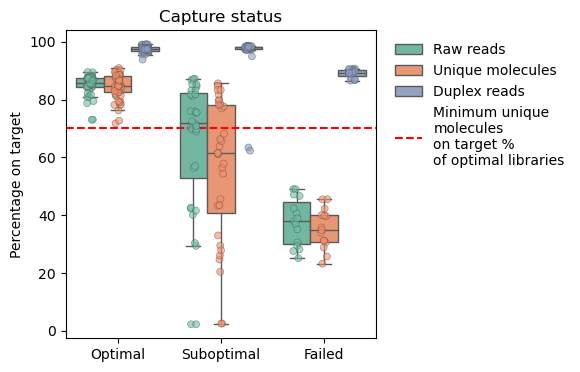

In [9]:
# your variables of interest
to_plot = [
    'BamQC>>raw.percentage_aligned_on_target',
    'BamQC>>am.percentage_aligned_on_target',
    'BamQC>>duplex.percentage_aligned_on_target',
    # 'FamMetrics>>on_target'
]

# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
                             'IDT016', 'IDT017', 'IDT018','IDT020',
                             'IDT015','IDT021', 'IDT022',
                             'IDT023', 'IDT019',
                             'IDT026',
                             'IDT027',
                             ])].copy()

mapping_batch_to_quality = {
        "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                    'IDT016', 'IDT017', 'IDT018','IDT020',
                    'IDT026','IDT027',
                    ],
        "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
        "Failed": [ 'IDT023', 'IDT019']
    }

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})

df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name="Percentage_on_target"
)

# rename Metric column for nicer display
long_df["Metric"] = long_df["Metric"].str.replace("BamQC>>", "").str.replace(".percentage_aligned_on_target", "")
long_df["Metric"] = long_df["Metric"].map({
    'raw': 'Raw reads',
    'am': 'Unique molecules',
    'duplex': 'Duplex reads',})
# set up plot
plt.figure(figsize=(4, 4))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y="Percentage_on_target",
    hue="Metric",
    palette="Set2",
    order = ["Optimal", "Suboptimal", "Failed"],
    showfliers=False
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y="Percentage_on_target",
    hue="Metric",
    dodge=True,
    alpha=0.6,
    order = ["Optimal", "Suboptimal", "Failed"],
    palette="Set2",
    linewidth=0.5,
    edgecolor="gray",
    legend=False
)
plt.axhline(y=70, color='red', linestyle='--', label='Minimum unique\nmolecules\non target %\nof optimal libraries')
# tidy up
plt.title("Capture status", fontsize=12)
plt.xlabel("")
plt.xticks(range(len(df["CaptureStatus"].unique())), ["Optimal", "Suboptimal", "Failed"])
plt.ylabel("Percentage on target")
# plt.xticks(range(len(df["PROJECT"].unique())), [f"Exp_{i}" for i in range(len(df["PROJECT"].unique()))])
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc='upper left', frameon =False)
# plt.tight_layout()
plt.savefig("../plots/capture_status_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()


### Conversion rate

/tmp/ipykernel_255695/340062769.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_255695/340062769.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


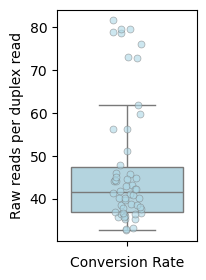

In [10]:
# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
    'IDT016', 'IDT017', 'IDT018','IDT020',
    'IDT015','IDT021', 'IDT022',
    'IDT023', 'IDT019',
    'IDT026',
    'IDT027',
])].copy()

mapping_batch_to_quality = {
    "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                'IDT016', 'IDT017', 'IDT018','IDT020',
                'IDT026','IDT027',
                ],
    "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
    "Failed": [ 'IDT023', 'IDT019']
}

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    "OptimalReadXDuplexRead"
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "lightblue",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "lightblue",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# tidy up
plt.title("", fontsize=12)
plt.ylabel("Raw reads per duplex read")
plt.xlabel("Conversion Rate")
plt.xticks([0],[])
plt.legend().remove()
# plt.tight_layout()
plt.savefig("../plots/sequencing_conversion_rate.deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_255695/2218218976.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_255695/2218218976.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


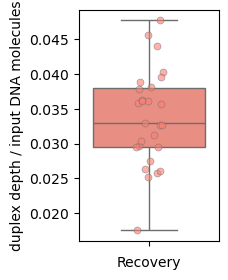

In [11]:
# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
    'IDT016', 'IDT017', 'IDT018','IDT020',
    'IDT015','IDT021', 'IDT022',
    'IDT023', 'IDT019',
    'IDT026',
    'IDT027',
])].copy()

mapping_batch_to_quality = {
    "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                'IDT016', 'IDT017', 'IDT018','IDT020',
                'IDT026','IDT027',
                ],
    "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
    "Failed": [ 'IDT023', 'IDT019']
}

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    'Combined>>recovery.input_ng2duplex_depth',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "salmon",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "salmon",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# # tidy up
plt.title("", fontsize=12)
plt.ylabel("duplex depth / input DNA molecules")
plt.xlabel("Recovery")
plt.xticks([0],[])
plt.legend().remove()
plt.savefig("../plots/recovery_plot.deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()

### ALT deepDLP metrics

In [12]:
alt_subset_data = data[~(data["PROJECT"].str.startswith("IDT"))
                       & ~(data["REAL_MEAN_DEPTH_ONTARGET"].isna())
                       ].copy()

alt_subset_data.shape

(29, 225)

/tmp/ipykernel_255695/467558862.py:33: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_255695/467558862.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


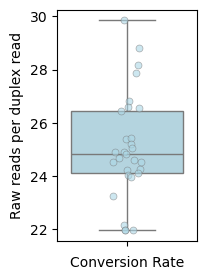

In [13]:
# subset data
df = alt_subset_data[alt_subset_data["OptimalReadXDuplexRead"]<60].copy()

df["CaptureStatus"] = "Optimal"
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    "OptimalReadXDuplexRead"
    # 'DryLab>>on_target.duplex.efficiency',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "lightblue",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "lightblue",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# tidy up
plt.title("", fontsize=12)
plt.ylabel("Raw reads per duplex read")
plt.xlabel("Conversion Rate")
plt.xticks([0],[])
plt.legend().remove()
# plt.tight_layout()
plt.savefig("../plots/sequencing_conversion_rate.ALT_deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_255695/3203247619.py:32: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


/tmp/ipykernel_255695/3203247619.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


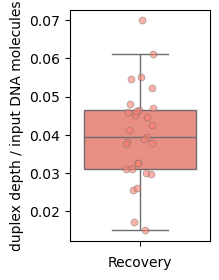

In [14]:
# subset data
df = alt_subset_data.copy()

df["CaptureStatus"] = "Optimal"
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    'Combined>>recovery.input_ng2duplex_depth',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "salmon",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "salmon",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# # tidy up
plt.title("", fontsize=12)
plt.ylabel("duplex depth / input DNA molecules")
plt.xlabel("Recovery")
plt.xticks([0],[])
plt.legend().remove()
plt.savefig("../plots/recovery_plot.ALT_deepDLP.pdf", dpi=300, bbox_inches='tight')
plt.show()
